In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [2]:
df = pd.read_parquet( os.path.join('Data', 'Parquet', 'threePointsTotal.parquet') )
tp = df.groupby('year').sum()
games_number = pd.Series(df['made_home'].groupby(df['year']).count())

In [3]:
tp['games'] = games_number

In [4]:
tp

,made_home,attempted_home,made_away,attempted_away,games
year,,,,,
1986,1010.0,3397.0,1106.0,3937.0,979
1987,1429.0,4526.0,1522.0,5092.0,981
1988,1784.0,5433.0,1817.0,5884.0,1064
1989,2546.0,7724.0,2486.0,7881.0,1121
1990,2646.0,7826.0,2671.0,8227.0,1185
1991,2933.0,8864.0,2771.0,8904.0,1184
1992,3112.0,9150.0,2993.0,9108.0,1147
1993,3751.0,11035.0,3767.0,11348.0,1193
1994,4431.0,12938.0,4425.0,12891.0,1109


In [5]:
tp['pct_home'] = (tp['made_home']/tp['attempted_home']*100).round(1)
tp['pct_away'] = (tp['made_away']/tp['attempted_away']*100).round(1)
tp['avg_made_home'] = (tp['made_home']/tp['games']).round(1)
tp['avg_attempted_home'] = (tp['attempted_home']/tp['games']).round(1)
tp['avg_made_away'] = (tp['made_away']/tp['games']).round(1)
tp['avg_attempted_away'] = (tp['attempted_away']/tp['games']).round(1)
tp

,made_home,attempted_home,made_away,attempted_away,games,pct_home,pct_away,avg_made_home,avg_attempted_home,avg_made_away,avg_attempted_away
year,,,,,,,,,,,
1986,1010.0,3397.0,1106.0,3937.0,979,29.7,28.1,1.0,3.5,1.1,4.0
1987,1429.0,4526.0,1522.0,5092.0,981,31.6,29.9,1.5,4.6,1.6,5.2
1988,1784.0,5433.0,1817.0,5884.0,1064,32.8,30.9,1.7,5.1,1.7,5.5
1989,2546.0,7724.0,2486.0,7881.0,1121,33.0,31.5,2.3,6.9,2.2,7.0
1990,2646.0,7826.0,2671.0,8227.0,1185,33.8,32.5,2.2,6.6,2.3,6.9
1991,2933.0,8864.0,2771.0,8904.0,1184,33.1,31.1,2.5,7.5,2.3,7.5
1992,3112.0,9150.0,2993.0,9108.0,1147,34.0,32.9,2.7,8.0,2.6,7.9
1993,3751.0,11035.0,3767.0,11348.0,1193,34.0,33.2,3.1,9.2,3.2,9.5
1994,4431.0,12938.0,4425.0,12891.0,1109,34.2,34.3,4.0,11.7,4.0,11.6


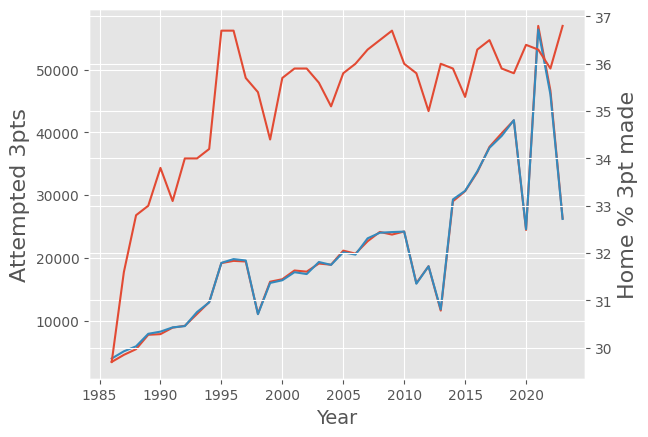

In [19]:
#define colors to use
col1 = ' steelblue '
col2 = ' red '

#define subplots
fig,ax=plt.subplots()

#add first line to plot
ax.plot(tp['attempted_home'])
ax.plot(tp['attempted_away'])
        
#add x-axis label
ax.set_xlabel('Year', fontsize= 14)

#add y-axis label
ax.set_ylabel('Attempted 3pts', fontsize= 16)

#define second y-axis that shares x-axis with current plot
ax2=ax.twinx()

#add second line to plot
ax2.plot(tp['pct_home'])

#add second y-axis label
ax2.set_ylabel('Home % 3pt made', fontsize= 16);
